In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
from pathlib import Path

import sys
sys.path.append('../../')

import phys_ml.visualization.vertex_visualization as vertvis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

# 04 Phase classification

In [3]:
from sklearn import ensemble, svm


info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
hidden_dims = [128, 64, 32, 8]
config_kwargs = {'path_train': '../../../frgs_6d', 
                 'hidden_dims': hidden_dims,
                 'epochs': 100,
                 'sample_count_per_vertex': 20000, 
                 'test_ratio': 0.2, 
                 'subset': -1, 
                 'subset_shuffle': True, 
                 'devices': 'auto', 
                 'num_dataloader_workers': 8, 
                 'strategy': 'auto', 
                 'batch_size': 8192}

seed = 12
pc_models = [
    # svm.SVC(verbose=True, random_state=seed + 1), 
    ensemble.RandomForestClassifier(n_jobs=-1, verbose=1, random_state=seed + 2),
]
train_samples_per_vertex = 20000
test_samples_per_vertex = 2000


def init_trainer(device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    config_kwargs['device_type'] = device_type
    for k, v in kwargs.items():
        config_kwargs[k] = v
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                                config_kwargs=config_kwargs)
    return trainer

## 04-1 All vertices

* evaluate amount of information captured in latent space
* see how well the phase can be classified from the latent space

In [ ]:
trainer = init_trainer(subset=None)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [60]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-20/version_4'

In [8]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-20/version_4'
pc = PhaseClassification(save_path, pc_models, 1)

In [5]:
pc.train(pc.vertex_trainer.dataset.file_paths, train_samples_per_vertex)

Load data:   0%|          | 0/51 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   18.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.0min finished


Predict:   0%|          | 0/1 [00:00<?, ?it/s]

Load data:   0%|          | 0/51 [00:00<?, ?it/s]

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.7s finished


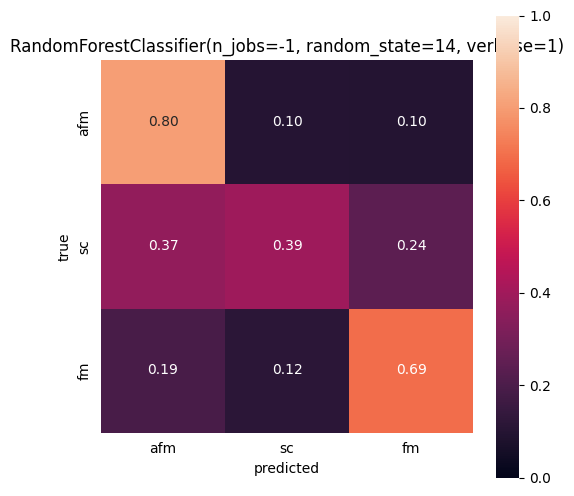

{'RandomForestClassifier(n_jobs=-1, random_state=14, verbose=1)': ({'acc': np.float64(0.629839245014245),
   'prec': 0.6597745098039216,
   'rec': 0.6597745098039216,
   'f1': 0.6597745098039216},
  array([[0.802725  , 0.100075  , 0.0972    ],
         [0.36561538, 0.39365385, 0.24073077],
         [0.19105556, 0.11580556, 0.69313889]]))}

In [9]:
model_scores = pc.evaluate_classifiers(pc.vertex_trainer.dataset.file_paths, test_samples_per_vertex, print_conf_mat=True)
with open(f'1_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 04-2 Train/Test-split within each phase

* determine how well classification works for each phase

In [ ]:
trainer = init_trainer(subset=0.8, subset_type='phase')
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [28]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-20/version_2'

In [10]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-20/version_2'
pc = PhaseClassification(save_path, pc_models, 2)

In [11]:
path_train = '../../../frgs_6d'
train_files = pc.vertex_trainer.dataset.file_paths
test_files = [f for f in glob.glob(f"{path_train}/*.h5") if f not in train_files]
pc.train(train_files, train_samples_per_vertex)

Load data:   0%|          | 0/40 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   13.5s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   44.7s finished


Predict:   0%|          | 0/1 [00:00<?, ?it/s]

Load data:   0%|          | 0/11 [00:00<?, ?it/s]

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.2s finished


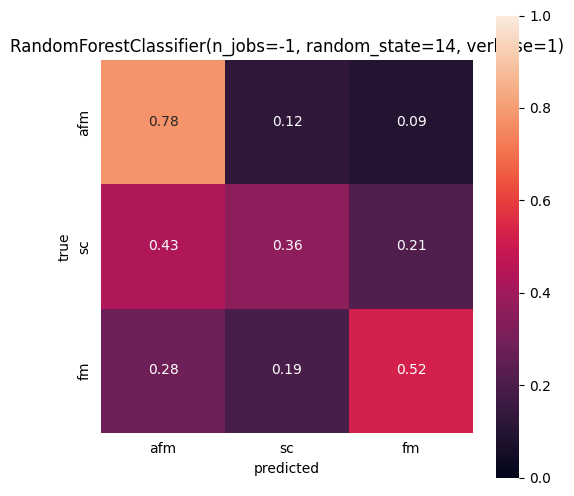

{'RandomForestClassifier(n_jobs=-1, random_state=14, verbose=1)': ({'acc': np.float64(0.5543472222222222),
   'prec': 0.5722727272727273,
   'rec': 0.5722727272727273,
   'f1': 0.5722727272727273},
  array([[0.781125  , 0.124     , 0.094875  ],
         [0.43016667, 0.35716667, 0.21266667],
         [0.283625  , 0.191625  , 0.52475   ]]))}

In [12]:
model_scores = pc.evaluate_classifiers(test_files, test_samples_per_vertex, print_conf_mat=True)
with open(f'2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 04-3 Use vertices from SC-phase as test set

* determine how well the phase can be extrapolated from latent space

In [ ]:
trainer = init_trainer(subset=None, subset_type=['afm', 'fm'])
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [30]:
trainer.config.save_path

'/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-20/version_3'

In [13]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-20/version_3'
pc = PhaseClassification(save_path, pc_models, 3)

In [14]:
path_train = '../../../frgs_6d'
train_files = pc.vertex_trainer.dataset.file_paths
test_files = [f for f in glob.glob(f"{path_train}/*.h5") if f not in train_files]
pc.train(train_files, train_samples_per_vertex)

Load data:   0%|          | 0/38 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   12.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   40.8s finished


Predict:   0%|          | 0/1 [00:00<?, ?it/s]

Load data:   0%|          | 0/13 [00:00<?, ?it/s]

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.2s finished
/gpfs/opt/sw/jupyterhub/envs/conda/vsc5/jupyterhub-llm-training-v4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


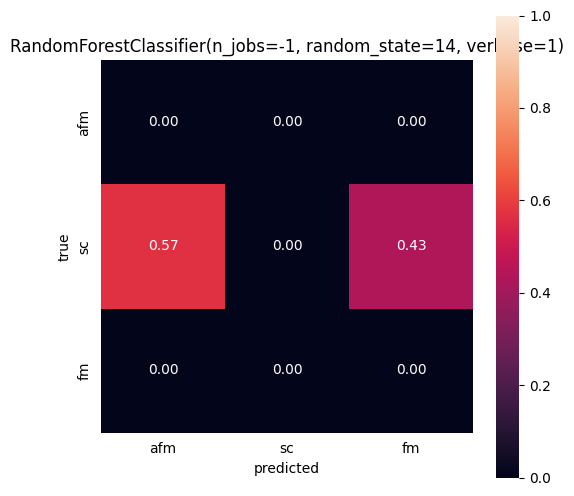

{'RandomForestClassifier(n_jobs=-1, random_state=14, verbose=1)': ({'acc': np.float64(0.0),
   'prec': 0.0,
   'rec': 0.0,
   'f1': 0.0},
  array([[0.        , 0.        , 0.        ],
         [0.56688462, 0.        , 0.43311538],
         [0.        , 0.        , 0.        ]]))}

In [15]:
model_scores = pc.evaluate_classifiers(test_files, test_samples_per_vertex, print_conf_mat=True)
with open(f'3_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

# 05 Phase regression

In [16]:
from sklearn import ensemble, svm


info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
hidden_dims = [128, 64, 32, 8]
config_kwargs = {'path_train': '../../../frgs_6d', 
                 'hidden_dims': hidden_dims,
                 'epochs': 100,
                 'sample_count_per_vertex': 20000, 
                 'test_ratio': 0.2, 
                 'subset': -1, 
                 'subset_shuffle': True, 
                 'devices': 'auto', 
                 'num_dataloader_workers': 8, 
                 'strategy': 'auto', 
                 'batch_size': 8192}

seed = 12
mode = 'r'
pc_models = [
    #svm.SVR(), 
    phase_classification.PolynomialRegression.new(degree=2),
    phase_classification.PolynomialRegression.new(degree=3),
    ensemble.RandomForestRegressor(n_jobs=-1, random_state=seed + 1),
]
train_samples_per_vertex = 20000
test_samples_per_vertex = 2000


def init_trainer(device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    config_kwargs['device_type'] = device_type
    for k, v in kwargs.items():
        config_kwargs[k] = v
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                                config_kwargs=config_kwargs)
    return trainer

## 05-1 All vertices

In [ ]:
trainer = init_trainer(subset=None)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

In [17]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-20/version_4'
pc = PhaseClassification(save_path, pc_models, 1, mode)

Model PolynomialRegression() is not fitted and could not be loaded. Call train() before using the PhaseClassifier.
Model PolynomialRegression(degree=3) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.
Model RandomForestRegressor(n_jobs=-1, random_state=13) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


In [18]:
pc.train(pc.vertex_trainer.dataset.file_paths, train_samples_per_vertex)

Load data:   0%|          | 0/51 [00:00<?, ?it/s]

Fit models:   0%|          | 0/3 [00:00<?, ?it/s]

Predict:   0%|          | 0/3 [00:00<?, ?it/s]

Load data:   0%|          | 0/51 [00:00<?, ?it/s]

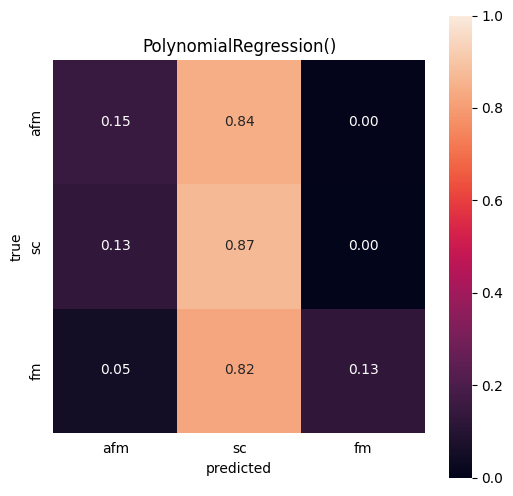

Load data:   0%|          | 0/51 [00:00<?, ?it/s]

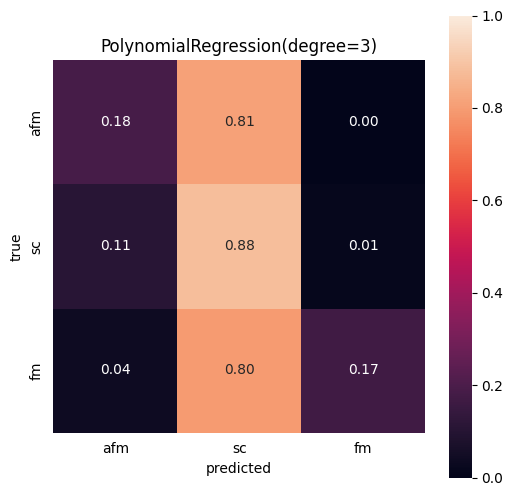

Load data:   0%|          | 0/51 [00:00<?, ?it/s]

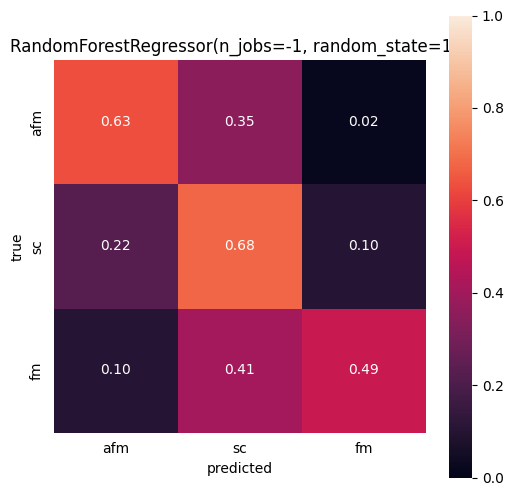

{'PolynomialRegression()': ({'rmse': 0.1386288898549091,
   'acc': np.float64(0.38279971509971505),
   'prec': 0.32622549019607844,
   'rec': 0.32622549019607844,
   'f1': 0.32622549019607844},
  array([[0.1521    , 0.84295   , 0.00495   ],
         [0.13061538, 0.86757692, 0.00180769],
         [0.04877778, 0.8225    , 0.12872222]])),
 'PolynomialRegression(degree=3)': ({'rmse': 0.13425945251601676,
   'acc': np.float64(0.4113841168091168),
   'prec': 0.35637254901960785,
   'rec': 0.35637254901960785,
   'f1': 0.35637254901960785},
  array([[0.183975  , 0.81235   , 0.003675  ],
         [0.10619231, 0.88153846, 0.01226923],
         [0.03516667, 0.79619444, 0.16863889]])),
 'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.10541523651265793,
   'acc': np.float64(0.5994782051282052),
   'prec': 0.5931274509803922,
   'rec': 0.5931274509803922,
   'f1': 0.5931274509803922},
  array([[0.6298    , 0.3518    , 0.0184    ],
         [0.22430769, 0.67638462, 0.09930769],
    

In [19]:
model_scores = pc.evaluate_classifiers(pc.vertex_trainer.dataset.file_paths, test_samples_per_vertex, print_conf_mat=True)
with open(f'1_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 05-2 Train/Test-split within each phase

In [ ]:
trainer = init_trainer(subset=0.8, subset_type='phase')
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

In [20]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-20/version_2'
pc = PhaseClassification(save_path, pc_models, 2, mode)

In [21]:
path_train = '../../../frgs_6d'
train_files = pc.vertex_trainer.dataset.file_paths
test_files = [f for f in glob.glob(f"{path_train}/*.h5") if f not in train_files]
pc.train(train_files, train_samples_per_vertex)

Load data:   0%|          | 0/40 [00:00<?, ?it/s]

Fit models:   0%|          | 0/3 [00:00<?, ?it/s]

Predict:   0%|          | 0/3 [00:00<?, ?it/s]

Load data:   0%|          | 0/11 [00:00<?, ?it/s]

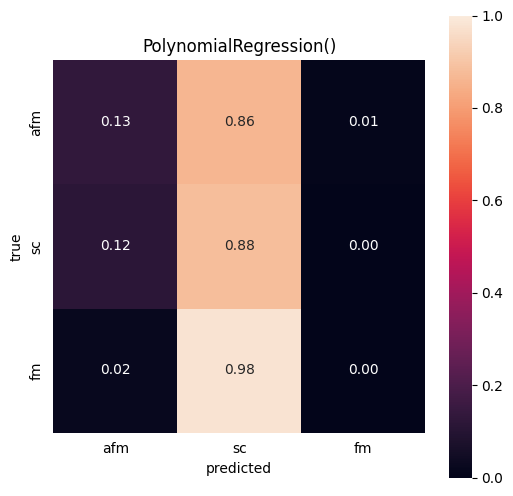

Load data:   0%|          | 0/11 [00:00<?, ?it/s]

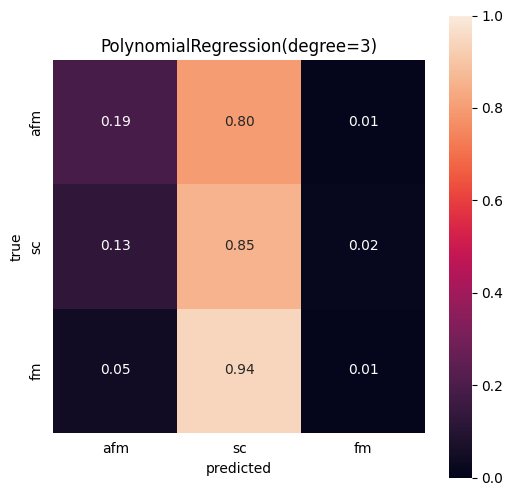

Load data:   0%|          | 0/11 [00:00<?, ?it/s]

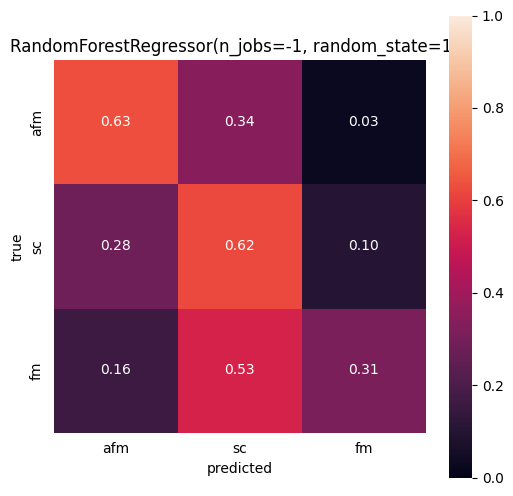

{'PolynomialRegression()': ({'rmse': 0.12351719152757364,
   'acc': np.float64(0.33947222222222223),
   'prec': 0.29009090909090907,
   'rec': 0.29009090909090907,
   'f1': 0.29009090909090907},
  array([[0.132125  , 0.859625  , 0.00825   ],
         [0.11533333, 0.88266667, 0.002     ],
         [0.01975   , 0.976625  , 0.003625  ]])),
 'PolynomialRegression(degree=3)': ({'rmse': 0.12381420066353631,
   'acc': np.float64(0.35223611111111114),
   'prec': 0.30654545454545457,
   'rec': 0.30654545454545457,
   'f1': 0.30654545454545457},
  array([[0.19025   , 0.800625  , 0.009125  ],
         [0.12733333, 0.85483333, 0.01783333],
         [0.045375  , 0.943     , 0.011625  ]])),
 'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.10429079213255771,
   'acc': np.float64(0.5205694444444444),
   'prec': 0.5115909090909091,
   'rec': 0.5115909090909091,
   'f1': 0.5115909090909091},
  array([[0.630375  , 0.3415    , 0.028125  ],
         [0.28133333, 0.61933333, 0.09933333],
  

In [22]:
model_scores = pc.evaluate_classifiers(test_files, test_samples_per_vertex, print_conf_mat=True)
with open(f'2_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

## 05-3 Use vertices from SC-phase as test set

* determine how well the phase can be extrapolated from latent space

In [ ]:
trainer = init_trainer(subset=None, subset_type=['afm', 'fm'])
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

In [23]:
save_path = '/gpfs/data/fs71925/shepp123/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS8192_2025-03-20/version_3'
pc = PhaseClassification(save_path, pc_models, 3, mode)

In [24]:
path_train = '../../../frgs_6d'
train_files = pc.vertex_trainer.dataset.file_paths
test_files = [f for f in glob.glob(f"{path_train}/*.h5") if f not in train_files]
pc.train(train_files, train_samples_per_vertex)

Load data:   0%|          | 0/38 [00:00<?, ?it/s]

Fit models:   0%|          | 0/3 [00:00<?, ?it/s]

Could not fit model PolynomialRegression(degree=3):
	Maximum number of iterations reached.


Predict:   0%|          | 0/3 [00:00<?, ?it/s]

Load data:   0%|          | 0/13 [00:00<?, ?it/s]

/gpfs/opt/sw/jupyterhub/envs/conda/vsc5/jupyterhub-llm-training-v4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


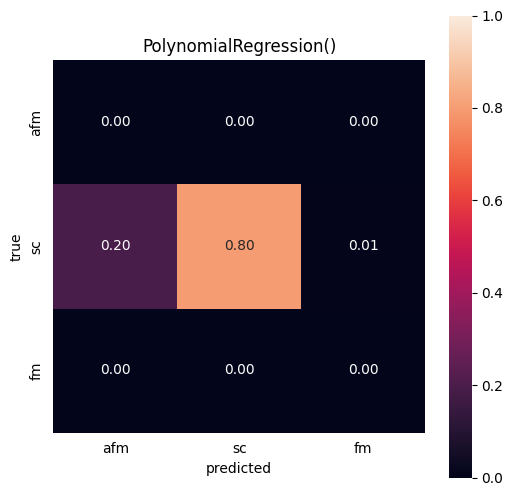

Load data:   0%|          | 0/13 [00:00<?, ?it/s]

/gpfs/opt/sw/jupyterhub/envs/conda/vsc5/jupyterhub-llm-training-v4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


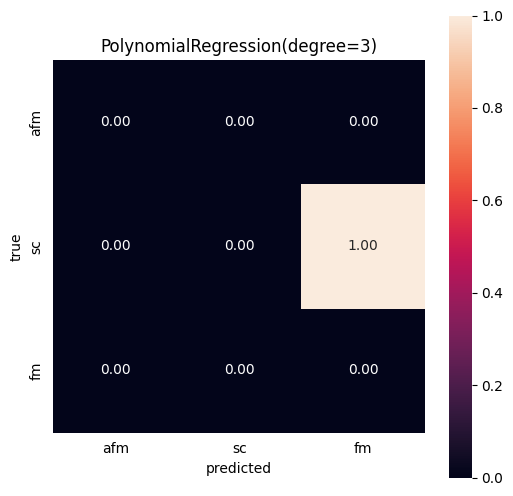

Load data:   0%|          | 0/13 [00:00<?, ?it/s]

/gpfs/opt/sw/jupyterhub/envs/conda/vsc5/jupyterhub-llm-training-v4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


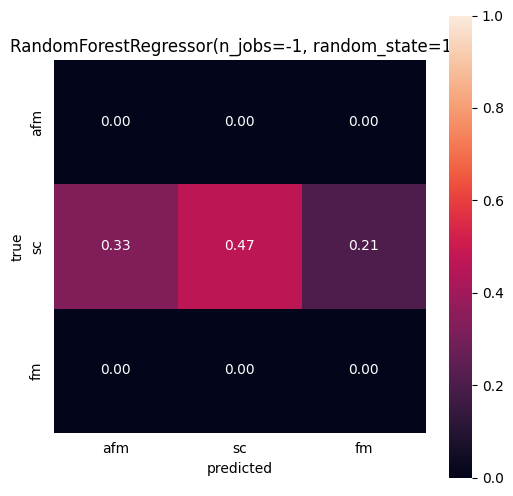

{'PolynomialRegression()': ({'rmse': 0.061498355677203305,
   'acc': np.float64(0.7988846153846154),
   'prec': 0.7988846153846154,
   'rec': 0.7988846153846154,
   'f1': 0.7988846153846154},
  array([[0.        , 0.        , 0.        ],
         [0.195     , 0.79888462, 0.00611538],
         [0.        , 0.        , 0.        ]])),
 'PolynomialRegression(degree=3)': ({'rmse': 87.13051680360839,
   'acc': np.float64(0.0),
   'prec': 0.0,
   'rec': 0.0,
   'f1': 0.0},
  array([[0., 0., 0.],
         [0., 0., 1.],
         [0., 0., 0.]])),
 'RandomForestRegressor(n_jobs=-1, random_state=13)': ({'rmse': 0.09060365217422361,
   'acc': np.float64(0.46823076923076923),
   'prec': 0.46823076923076923,
   'rec': 0.46823076923076923,
   'f1': 0.46823076923076923},
  array([[0.        , 0.        , 0.        ],
         [0.32557692, 0.46823077, 0.20619231],
         [0.        , 0.        , 0.        ]]))}

In [25]:
model_scores = pc.evaluate_classifiers(test_files, test_samples_per_vertex, print_conf_mat=True)
with open(f'3_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)
model_scores

# ---